In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('application.csv', delimiter = ',')

In [ ]:
data.drop(['Unnamed: 0'], axis=1, inplace=True)

In [ ]:
features = data.drop('TARGET', axis=1)

for col in features.columns:
    if features[col].dtype == 'bool':
        features[col] = features[col].astype(int)

In [ ]:
data

,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,OWN_CAR_AGE,LIVINGAREA_AVG,...,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
0,0,1,6.458338,12.218500,12.915581,10.114619,12.768544,0,2.302585,0.018822,...,False,False,False,True,False,True,False,False,False,False
1,0,0,7.080868,12.506181,14.072865,10.482892,13.937287,0,2.302585,0.053446,...,True,False,False,False,False,True,False,False,False,False
2,1,1,5.420535,11.119898,11.813037,8.817446,11.813037,0,3.295837,0.071855,...,False,False,False,True,False,True,False,False,False,False
3,0,1,8.019613,11.813037,12.652947,10.298481,12.601491,0,2.302585,0.071855,...,False,False,False,True,False,True,False,False,False,False
4,0,1,8.019284,11.707678,13.148033,9.992711,13.148033,0,2.302585,0.071855,...,False,False,False,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239143,0,1,8.889997,11.938200,12.712652,9.686419,12.323860,0,2.302585,0.071855,...,False,False,False,True,False,True,False,False,False,False
239144,0,0,5.468060,11.967187,12.447846,10.224084,12.323860,0,2.302585,0.179401,...,False,False,False,True,False,False,False,False,False,True
239145,0,1,8.977399,11.938200,13.426408,10.308286,13.279369,0,2.302585,0.656431,...,True,False,False,False,False,True,False,False,False,False
239146,0,1,8.473659,12.049425,12.821550,9.913735,12.674516,0,2.302585,0.006081,...,False,False,False,True,False,True,False,False,False,False


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239148 entries, 0 to 239147
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   FLAG_OWN_CAR                   239148 non-null  int64  
 1   FLAG_OWN_REALTY                239148 non-null  int64  
 2   DAYS_EMPLOYED                  239148 non-null  float64
 3   AMT_INCOME_TOTAL               239148 non-null  float64
 4   AMT_CREDIT                     239148 non-null  float64
 5   AMT_ANNUITY                    239148 non-null  float64
 6   AMT_GOODS_PRICE                239148 non-null  float64
 7   CNT_CHILDREN                   239148 non-null  int64  
 8   OWN_CAR_AGE                    239148 non-null  float64
 9   LIVINGAREA_AVG                 239148 non-null  float64
 10  TARGET                         239148 non-null  int64  
 11  Academic degree                239148 non-null  bool   
 12  Higher education              

# Первоначальный многомерный анализ

## Расчет корреляционной матрицы


In [ ]:
correlation_matrix = data.corr()
print("Correlation matrix calculated successfully.")

Correlation matrix calculated successfully.


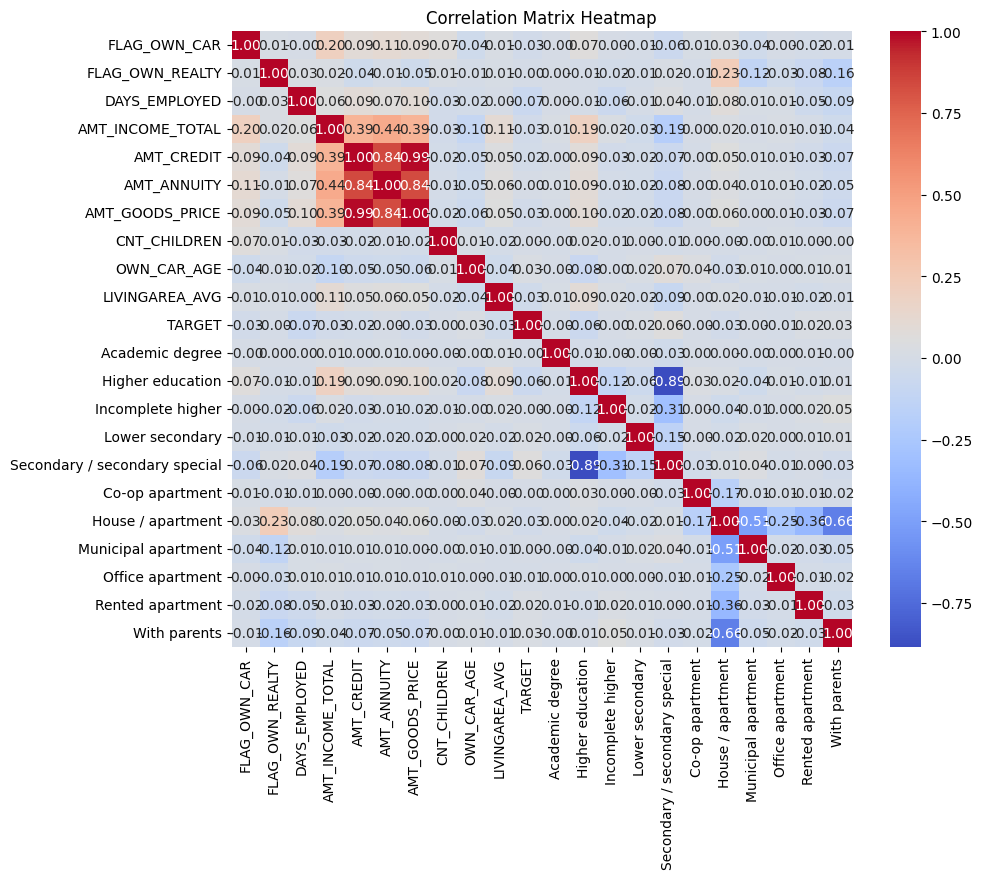

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()


Рассмотрим детальнее корреляцию между целевым признаком и остальными

In [ ]:
target_correlations = correlation_matrix['TARGET'].sort_values(ascending=False)
print("Корреляция с признаком TARGET:")
print(target_correlations)

Корреляция с признаком TARGET:
TARGET                           1.000000
Secondary / secondary special    0.057605
With parents                     0.027079
OWN_CAR_AGE                      0.026488
Rented apartment                 0.020142
Lower secondary                  0.017092
CNT_CHILDREN                     0.004982
Municipal apartment              0.002094
Incomplete higher               -0.000218
Co-op apartment                 -0.000292
AMT_ANNUITY                     -0.000974
FLAG_OWN_REALTY                 -0.003084
Academic degree                 -0.004948
Office apartment                -0.006701
AMT_CREDIT                      -0.019062
House / apartment               -0.026644
AMT_INCOME_TOTAL                -0.028504
AMT_GOODS_PRICE                 -0.030056
FLAG_OWN_CAR                    -0.030293
LIVINGAREA_AVG                  -0.033191
Higher education                -0.064177
DAYS_EMPLOYED                   -0.074475
Name: TARGET, dtype: float64


## Построение диаграмм рассеяния

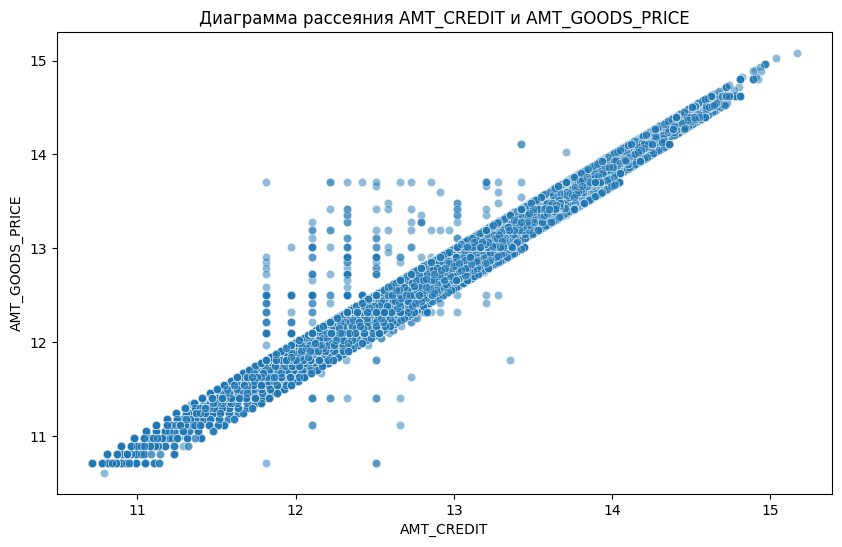

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AMT_CREDIT', y='AMT_GOODS_PRICE', data=data, alpha=0.5)
plt.title('Диаграмма рассеяния AMT_CREDIT и AMT_GOODS_PRICE')
plt.xlabel('AMT_CREDIT')
plt.ylabel('AMT_GOODS_PRICE')
plt.show()

# Продвинутые методы многомерного анализа

## Анализ главных компонент

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(features)

PCA()

Проанализируем коэффициент дисперсии каждой компоненты.

In [ ]:
explained_variance_ratio = pca.explained_variance_ratio_
print("Объясненная дисперсия каждой основной компоненты:")
print(explained_variance_ratio)

Объясненная дисперсия каждой основной компоненты:
[2.96158326e-01 2.40339119e-01 1.04659757e-01 8.71553507e-02
 5.70263207e-02 5.34885031e-02 5.11965161e-02 3.07036072e-02
 2.84065970e-02 1.44837551e-02 1.27193487e-02 1.00417967e-02
 5.17299225e-03 2.66212443e-03 2.38078855e-03 1.32712280e-03
 1.03427276e-03 9.02519737e-04 1.41182501e-04 3.75527544e-18
 0.00000000e+00]


Визуализируем соотношение объясняемой дисперсии и количества компонент. Это поможет определить оптимальное количество компонент.


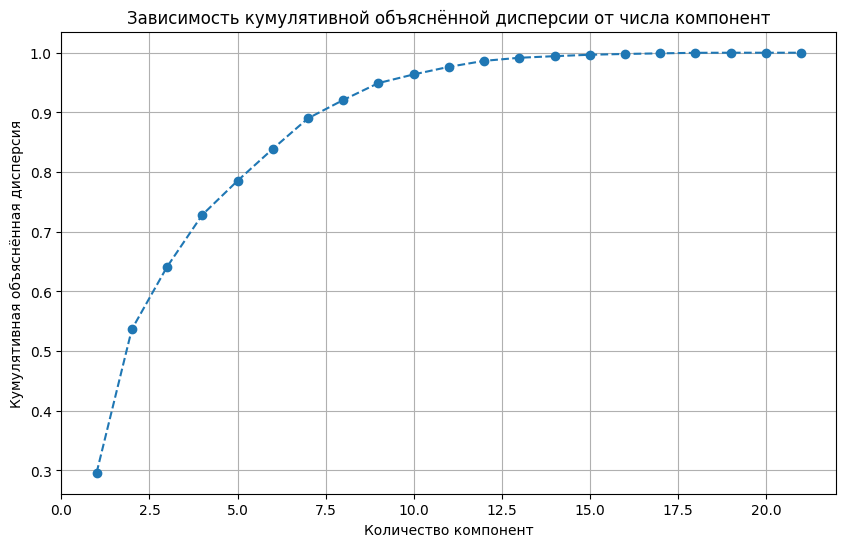

In [ ]:
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная объяснённая дисперсия')
plt.title('Зависимость кумулятивной объяснённой дисперсии от числа компонент')
plt.grid(True)
plt.show()

Первые несколько компонент отражают значительную часть общей дисперсии. Это указывает на то, что большая часть информации в наборе данных сосредоточена в меньшем количестве измерений.

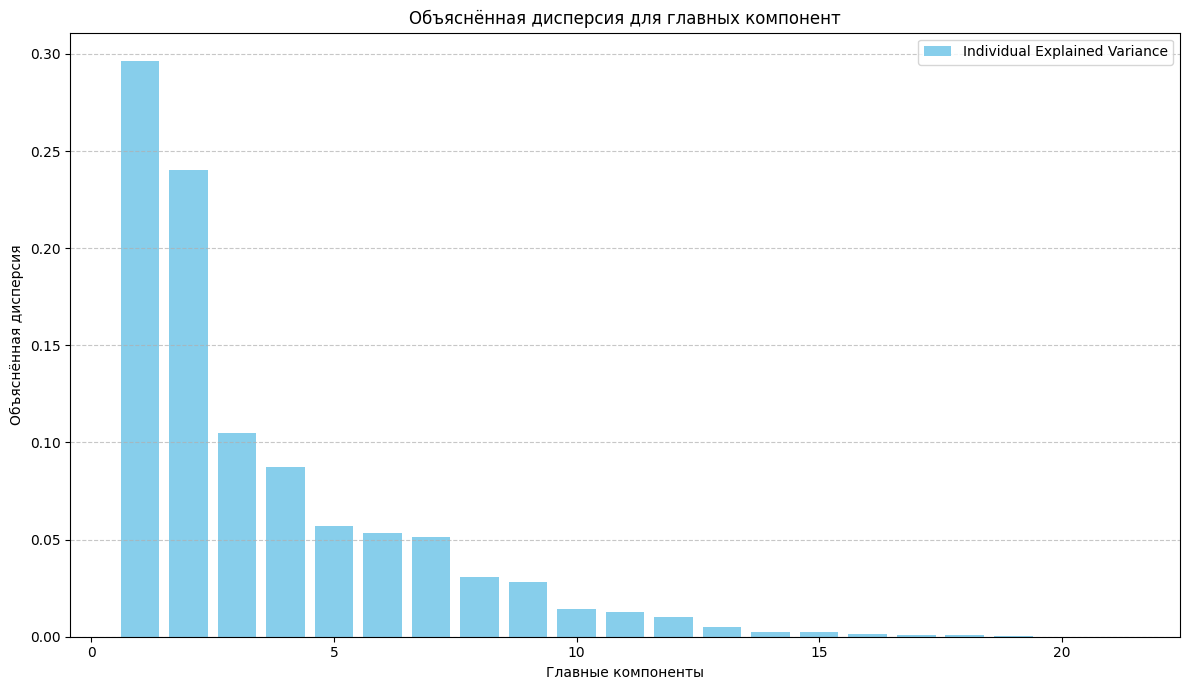

In [ ]:
# Create a scree plot for individual explained variance ratio
plt.figure(figsize=(12, 7))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, color='skyblue', label='Individual Explained Variance')
plt.xlabel('Главные компоненты')
plt.ylabel('Объяснённая дисперсия')
plt.title('Объяснённая дисперсия для главных компонент')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

Исходя из графиков, можно установить, что оптимальное количество компонент - 7.

## UMAP

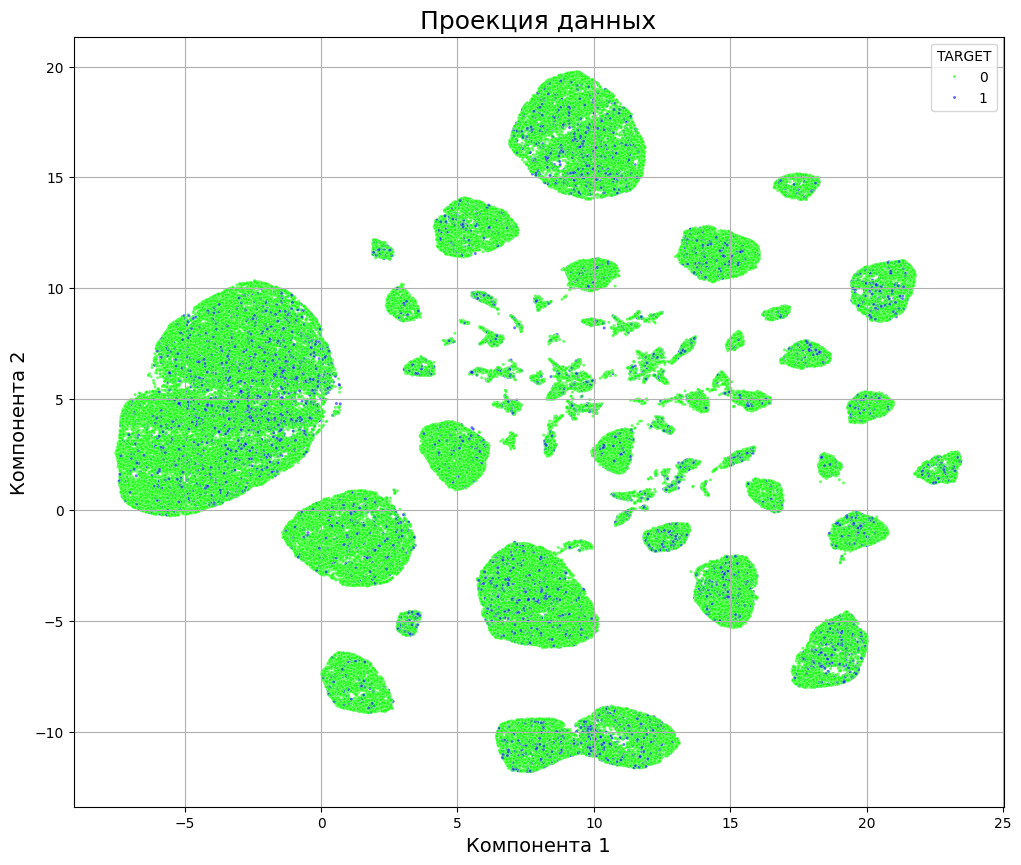

In [ ]:
import umap

# Выберем 2 компоненты для визуализации
reducer = umap.UMAP(n_components=2)

umap_embedding = reducer.fit_transform(features)

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=umap_embedding[:, 0],
    y=umap_embedding[:, 1],
    hue=data['TARGET'],
    palette=sns.color_palette('hsv', 2),
    s=5,
    alpha=0.6
)
plt.title('Проекция данных', fontsize=18)
plt.xlabel('Компонента 1', fontsize=14)
plt.ylabel('Компонента 2', fontsize=14)
plt.legend(title='TARGET')
plt.grid(True)
plt.show()

## Факторный анализ

In [ ]:
from sklearn.decomposition import FactorAnalysis

# Воспользуемся факторным анализом с with n_components=7
fa = FactorAnalysis(n_components=7, max_iter=1000)
fa.fit(features)

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(


FactorAnalysis(n_components=7)

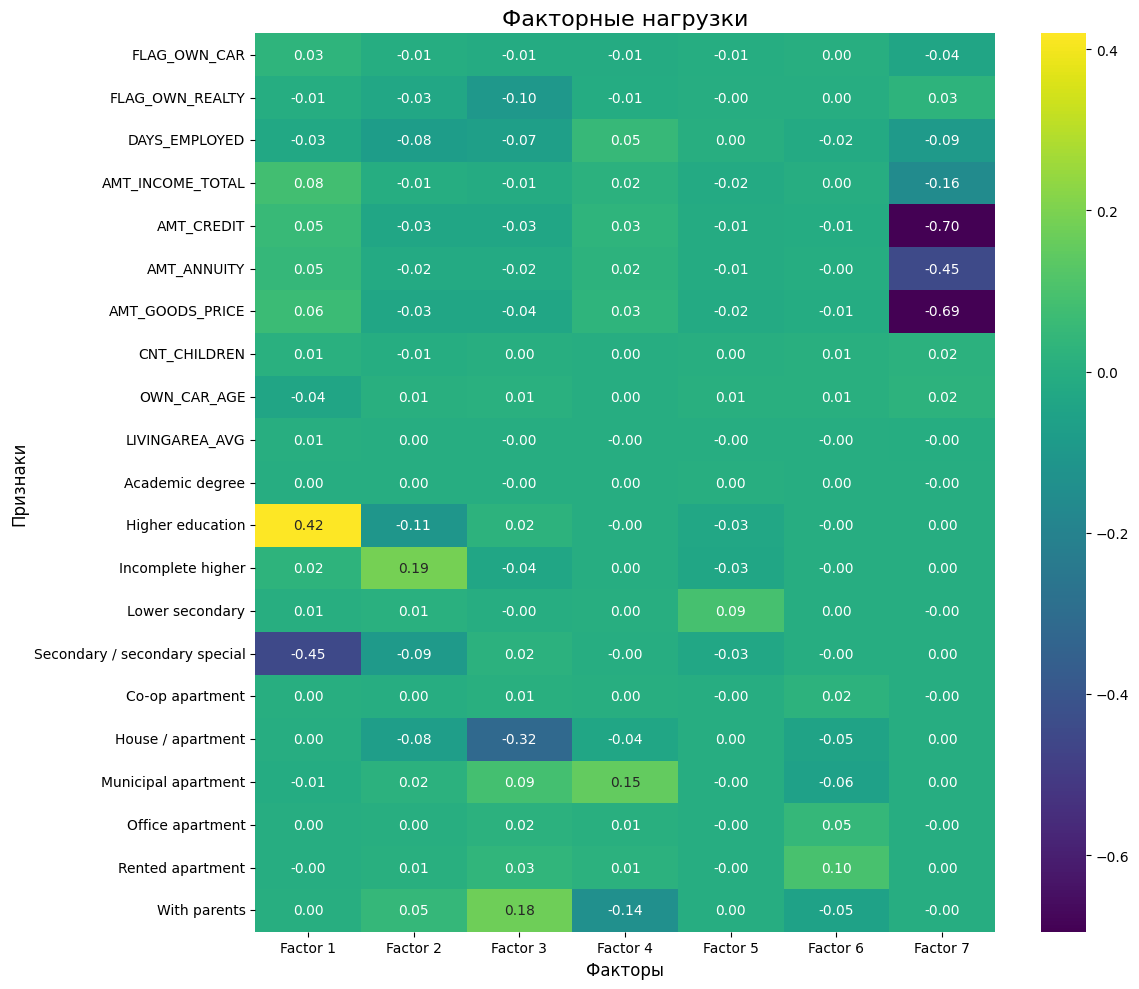

Визуализация факторных нагрузок завершена.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Получение факторных нагрузок
factor_loadings = fa.components_

factor_loadings_df = pd.DataFrame(
    factor_loadings.T, # Транспонируем для того, чтобы признаки были строками, а факторы - столбцами
    index=features.columns,
    columns=[f'Factor {i+1}' for i in range(fa.n_components)] # Использование fa.n_components
)

# Визуализация факторных нагрузок с помощью тепловой карты
plt.figure(figsize=(12, 10))
sns.heatmap(factor_loadings_df, cmap='viridis', annot=True, fmt=".2f")
plt.title('Факторные нагрузки', fontsize=16)
plt.xlabel('Факторы', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.tight_layout()
plt.show()

## Кластерный анализ

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

Определение оптимального количества кластеров


In [ ]:
from sklearn.cluster import KMeans

sse = []
k_range = range(1, 20)

# Цикл для расчета SSE для каждого k
for k in k_range:
    # Инициализация KMeans с текущим k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(features_scaled)
    sse.append(kmeans.inertia_)

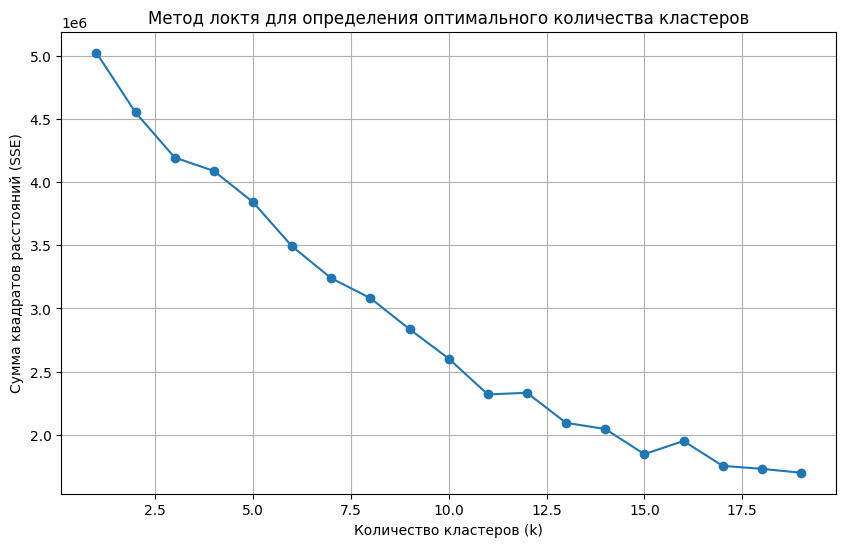

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов расстояний (SSE)')
plt.title('Метод локтя для определения оптимального количества кластеров')
plt.grid(True)
plt.show()

Возьмем 15 кластеров как оптимальное количество

In [ ]:
from sklearn.cluster import KMeans

k_optimal = 15

# Создание экземпляра KMeans с оптимальным количеством кластеров
kmeans_model = KMeans(n_clusters=k_optimal, random_state=42, n_init='auto')
kmeans_model.fit(features_scaled)

cluster_labels = kmeans_model.labels_
data['cluster_label'] = cluster_labels

print(f"K-Means clustering applied with k={k_optimal} clusters.")
print("Cluster labels added to the 'data' DataFrame.")

K-Means clustering applied with k=15 clusters.
Cluster labels added to the 'data' DataFrame.


Визуализируем кластеры


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


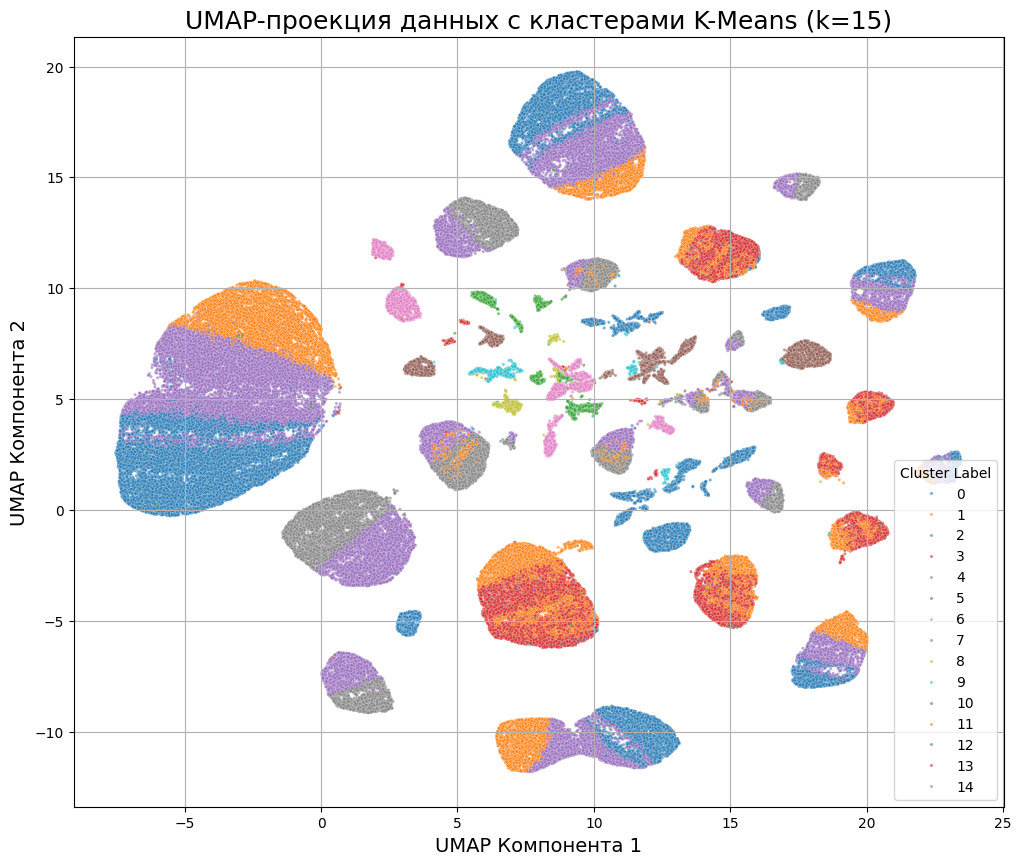

In [ ]:
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=umap_embedding[:, 0],
    y=umap_embedding[:, 1],
    hue=data['cluster_label'],
    palette=sns.color_palette('tab10', n_colors=k_optimal),
    s=5,
    alpha=0.6
)
plt.title(f'UMAP-проекция данных с кластерами K-Means (k={k_optimal})', fontsize=18)
plt.xlabel('UMAP Компонента 1', fontsize=14)
plt.ylabel('UMAP Компонента 2', fontsize=14)
plt.legend(title='Cluster Label')
plt.grid(True)
plt.show()

In [ ]:
cluster_characteristics = data.groupby('cluster_label').mean(numeric_only=True)
print("Средние значения признаков для каждого кластера:")
print(cluster_characteristics)

Средние значения признаков для каждого кластера:
               FLAG_OWN_CAR  FLAG_OWN_REALTY  DAYS_EMPLOYED  AMT_INCOME_TOTAL  \
cluster_label                                                                   
0                  0.007622         0.733301       7.550193         12.068974   
1                  1.000000         0.722879       7.411974         12.135924   
2                  0.307240         0.420588       6.909039         11.895712   
3                  0.426919         0.613039       7.164601         11.923400   
4                  0.345334         0.730865       7.180741         11.839269   
5                  0.272899         0.378305       7.358810         11.930693   
6                  0.376444         0.646084       6.968919         11.968704   
7                  0.431061         0.688604       7.406092         12.201675   
8                  0.383962         0.518868       7.397520         11.979216   
9                  0.322341         0.621923       7.198445 

# Дополнительные методы создания признаков

## Генерация взаимодействий признаков

In [ ]:
features_extended = features.copy()

# 1. Взаимодействие между 'DAYS_EMPLOYED' и 'AMT_INCOME_TOTAL' (оба имели относительно сильную корреляцию с TARGET)
features_extended['DAYS_EMPLOYED_x_AMT_INCOME_TOTAL'] = features_extended['DAYS_EMPLOYED'] * features_extended['AMT_INCOME_TOTAL']

# 2. Взаимодействие между 'AMT_CREDIT' и 'Secondary / secondary special' (финансовый признак с образованием, имеющим положительную корреляцию)
features_extended['AMT_CREDIT_x_SECONDARY_EDUCATION'] = features_extended['AMT_CREDIT'] * features_extended['Secondary / secondary special']

features_extended[['DAYS_EMPLOYED_x_AMT_INCOME_TOTAL',
                   'AMT_CREDIT_x_SECONDARY_EDUCATION']]


,DAYS_EMPLOYED_x_AMT_INCOME_TOTAL,AMT_CREDIT_x_SECONDARY_EDUCATION
0,78.911207,12.915581
1,88.554615,0.000000
2,60.275795,11.813037
3,94.735986,12.652947
4,93.887191,13.148033
...,...,...
239143,106.130564,12.712652
239144,65.437299,12.447846
239145,107.173982,0.000000
239146,102.102718,12.821550


## Генерация полиномиальных признаков

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

selected_features_for_poly = features.columns[:5].tolist()
print(f"Выбранные признаки для генерации полиномиальных комбинаций: {selected_features_for_poly}")

poly = PolynomialFeatures(degree=2, include_bias=False)

# Генерируем полиномиальные признаки только на основе выбранных признаков
features_polynomial_selected = poly.fit_transform(features[selected_features_for_poly])

poly_feature_names_selected = poly.get_feature_names_out(selected_features_for_poly)

features_polynomial_df = pd.DataFrame(features_polynomial_selected, columns=poly_feature_names_selected, index=features.index)

print("Генерация полиномиальных признаков завершена. Размерность нового набора признаков:")
print(features_polynomial_df.shape)
print("Первые 5 строк нового набора полиномиальных признаков:")
display(features_polynomial_df.head())

Выбранные признаки для генерации полиномиальных комбинаций: ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT']
Генерация полиномиальных признаков завершена. Размерность нового набора признаков:
(239148, 20)
Первые 5 строк нового набора полиномиальных признаков:


,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,FLAG_OWN_CAR^2,FLAG_OWN_CAR FLAG_OWN_REALTY,FLAG_OWN_CAR DAYS_EMPLOYED,FLAG_OWN_CAR AMT_INCOME_TOTAL,FLAG_OWN_CAR AMT_CREDIT,FLAG_OWN_REALTY^2,FLAG_OWN_REALTY DAYS_EMPLOYED,FLAG_OWN_REALTY AMT_INCOME_TOTAL,FLAG_OWN_REALTY AMT_CREDIT,DAYS_EMPLOYED^2,DAYS_EMPLOYED AMT_INCOME_TOTAL,DAYS_EMPLOYED AMT_CREDIT,AMT_INCOME_TOTAL^2,AMT_INCOME_TOTAL AMT_CREDIT,AMT_CREDIT^2
0,0.0,1.0,6.458338,12.218500,12.915581,0.0,0.0,0.000000,0.000000,0.000000,1.0,6.458338,12.218500,12.915581,41.710133,78.911207,83.413194,149.291745,157.809034,166.812245
1,0.0,0.0,7.080868,12.506181,14.072865,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,50.138690,88.554615,99.648098,156.404562,175.997796,198.045529
2,1.0,1.0,5.420535,11.119898,11.813037,1.0,1.0,5.420535,11.119898,11.813037,1.0,5.420535,11.119898,11.813037,29.382200,60.275795,64.032983,123.652125,131.359768,139.547854
3,0.0,1.0,8.019613,11.813037,12.652947,0.0,0.0,0.000000,0.000000,0.000000,1.0,8.019613,11.813037,12.652947,64.314189,94.735986,101.471734,139.547854,149.469734,160.097062
4,0.0,1.0,8.019284,11.707678,13.148033,0.0,0.0,0.000000,0.000000,0.000000,1.0,8.019284,11.707678,13.148033,64.308913,93.887191,105.437809,137.069719,153.932935,172.870774


## Биннинг и дискретизация

In [ ]:
import pandas as pd

# Создаем копию DataFrame для добавления новых признаков
features_binned = features.copy()

# --- Биннинг по равным интервалам (Equal-width binning) ---
# Пример для 'AMT_INCOME_TOTAL': разделим на 5 интервалов равной ширины
features_binned['AMT_INCOME_TOTAL_BINS'] = pd.cut(
    features_binned['AMT_INCOME_TOTAL'],
    bins=5, # Количество бинов
    labels=[f'Income_Bin_{i+1}' for i in range(5)], # Метки для бинов
    include_lowest=True # Включать самое низкое значение
)

print("Распределение для 'AMT_INCOME_TOTAL_BINS' (биннинг по равным интервалам):")
display(features_binned['AMT_INCOME_TOTAL_BINS'].value_counts().sort_index())
print("\nПервые 5 строк с новым признаком 'AMT_INCOME_TOTAL_BINS':")
display(features_binned[['AMT_INCOME_TOTAL', 'AMT_INCOME_TOTAL_BINS']].head())

# --- Биннинг по равным частотам (Equal-frequency binning) ---
# Пример для 'DAYS_EMPLOYED': разделим на 4 интервала с равным количеством наблюдений
features_binned['DAYS_EMPLOYED_QUARTILES'] = pd.qcut(
    features_binned['DAYS_EMPLOYED'],
    q=4, # Количество квантилей (интервалов равной частоты)
    labels=[f'DaysEmployed_Q{i+1}' for i in range(4)], # Метки для квантилей
    duplicates='drop' # Обработка дубликатов на границах квантилей
)

print("\nРаспределение для 'DAYS_EMPLOYED_QUARTILES' (биннинг по равным частотам):")
display(features_binned['DAYS_EMPLOYED_QUARTILES'].value_counts().sort_index())
print("\nПервые 5 строк с новым признаком 'DAYS_EMPLOYED_QUARTILES':")
display(features_binned[['DAYS_EMPLOYED', 'DAYS_EMPLOYED_QUARTILES']].head())

print("\nБиннинг и дискретизация успешно выполнены для выбранных признаков.")

Распределение для 'AMT_INCOME_TOTAL_BINS' (биннинг по равным интервалам):


,count
AMT_INCOME_TOTAL_BINS,
Income_Bin_1,496
Income_Bin_2,13088
Income_Bin_3,63324
Income_Bin_4,109122
Income_Bin_5,53118



Первые 5 строк с новым признаком 'AMT_INCOME_TOTAL_BINS':


,AMT_INCOME_TOTAL,AMT_INCOME_TOTAL_BINS
0,12.218500,Income_Bin_4
1,12.506181,Income_Bin_5
2,11.119898,Income_Bin_2
3,11.813037,Income_Bin_4
4,11.707678,Income_Bin_3



Распределение для 'DAYS_EMPLOYED_QUARTILES' (биннинг по равным частотам):


,count
DAYS_EMPLOYED_QUARTILES,
DaysEmployed_Q1,59847
DaysEmployed_Q2,59749
DaysEmployed_Q3,59786
DaysEmployed_Q4,59766



Первые 5 строк с новым признаком 'DAYS_EMPLOYED_QUARTILES':


,DAYS_EMPLOYED,DAYS_EMPLOYED_QUARTILES
0,6.458338,DaysEmployed_Q1
1,7.080868,DaysEmployed_Q2
2,5.420535,DaysEmployed_Q1
3,8.019613,DaysEmployed_Q3
4,8.019284,DaysEmployed_Q3



Биннинг и дискретизация успешно выполнены для выбранных признаков.


## Методы отбора признаков

In [ ]:
X = features.copy()
y = data['TARGET']

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

estimator = LogisticRegression(solver='liblinear', random_state=42)

rfe_selector = RFE(estimator=estimator, n_features_to_select=10, step=1)

rfe_selector.fit(X, y)

RFE(estimator=LogisticRegression(random_state=42, solver='liblinear'),
    n_features_to_select=10)

In [ ]:
selected_features_mask = rfe_selector.support_
ranked_features = rfe_selector.ranking_

selected_feature_names = X.columns[selected_features_mask]

print("Выбранные признаки:")
print(selected_feature_names.tolist())

print("\nРанг признака")
feature_ranking = pd.Series(ranked_features, index=X.columns)
print(feature_ranking.sort_values())

Выбранные признаки:
['DAYS_EMPLOYED', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'LIVINGAREA_AVG', 'Academic degree', 'Higher education', 'Lower secondary', 'Rented apartment', 'With parents']

Ранг признака
DAYS_EMPLOYED                     1
AMT_GOODS_PRICE                   1
AMT_ANNUITY                       1
AMT_CREDIT                        1
Lower secondary                   1
Higher education                  1
Academic degree                   1
LIVINGAREA_AVG                    1
With parents                      1
Rented apartment                  1
Office apartment                  2
Incomplete higher                 3
FLAG_OWN_CAR                      4
OWN_CAR_AGE                       5
Municipal apartment               6
House / apartment                 7
AMT_INCOME_TOTAL                  8
Secondary / secondary special     9
Co-op apartment                  10
CNT_CHILDREN                     11
FLAG_OWN_REALTY                  12
dtype: int64


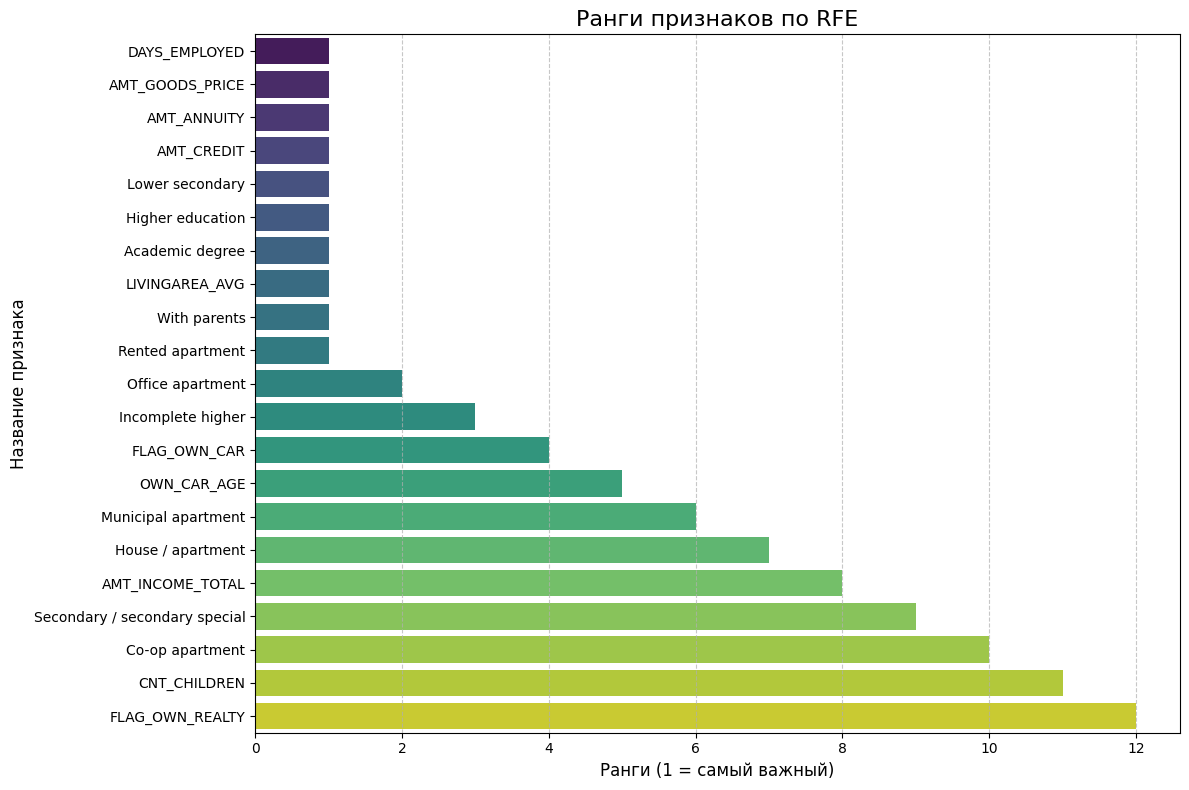

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for visualization
feature_ranking_df = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': ranked_features
})

feature_ranking_df = feature_ranking_df.sort_values(by='Ranking', ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x='Ranking', y='Feature', data=feature_ranking_df, palette='viridis', hue='Feature', legend=False)
plt.title('Ранги признаков по RFE', fontsize=16)
plt.xlabel('Ранги (1 = самый важный)', fontsize=12)
plt.ylabel('Название признака', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

estimator = LogisticRegression(solver='liblinear', random_state=42)

rfe_selector = RFE(estimator=estimator, n_features_to_select=10, step=1)

rfe_selector.fit(X, y)

ValueError: Cannot cast object dtype to float64

In [ ]:
# Извлекаем только новые признаки взаимодействия
interaction_features = features_extended[['DAYS_EMPLOYED_x_AMT_INCOME_TOTAL', 'AMT_CREDIT_x_SECONDARY_EDUCATION']]

# Извлекаем только новые биннинговые признаки
binned_features = features_binned[['AMT_INCOME_TOTAL_BINS', 'DAYS_EMPLOYED_QUARTILES']]

# Отфильтровываем из features_polynomial_df только новые полиномиальные признаки,
# исключая базовые признаки, которые уже есть в 'data'
new_polynomial_features_only = features_polynomial_df.drop(columns=selected_features_for_poly, errors='ignore')

# Объединяем все датафреймы по индексу
# Убеждаемся, что все исходные датафреймы имеют один и тот же индекс
main = pd.concat([
    data,
    interaction_features,
    binned_features,
    new_polynomial_features_only
], axis=1)

print(f"Объединенный датафрейм 'main' создан с {main.shape[0]} строками и {main.shape[1]} столбцами.")
print("Первые 5 строк датафрейма 'main':")
display(main.head())

Объединенный датафрейм 'main' создан с 239148 строками и 42 столбцами.
Первые 5 строк датафрейма 'main':


,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,OWN_CAR_AGE,LIVINGAREA_AVG,...,FLAG_OWN_REALTY^2,FLAG_OWN_REALTY DAYS_EMPLOYED,FLAG_OWN_REALTY AMT_INCOME_TOTAL,FLAG_OWN_REALTY AMT_CREDIT,DAYS_EMPLOYED^2,DAYS_EMPLOYED AMT_INCOME_TOTAL,DAYS_EMPLOYED AMT_CREDIT,AMT_INCOME_TOTAL^2,AMT_INCOME_TOTAL AMT_CREDIT,AMT_CREDIT^2
0,0,1,6.458338,12.218500,12.915581,10.114619,12.768544,0,2.302585,0.018822,...,1.0,6.458338,12.218500,12.915581,41.710133,78.911207,83.413194,149.291745,157.809034,166.812245
1,0,0,7.080868,12.506181,14.072865,10.482892,13.937287,0,2.302585,0.053446,...,0.0,0.000000,0.000000,0.000000,50.138690,88.554615,99.648098,156.404562,175.997796,198.045529
2,1,1,5.420535,11.119898,11.813037,8.817446,11.813037,0,3.295837,0.071855,...,1.0,5.420535,11.119898,11.813037,29.382200,60.275795,64.032983,123.652125,131.359768,139.547854
3,0,1,8.019613,11.813037,12.652947,10.298481,12.601491,0,2.302585,0.071855,...,1.0,8.019613,11.813037,12.652947,64.314189,94.735986,101.471734,139.547854,149.469734,160.097062
4,0,1,8.019284,11.707678,13.148033,9.992711,13.148033,0,2.302585,0.071855,...,1.0,8.019284,11.707678,13.148033,64.308913,93.887191,105.437809,137.069719,153.932935,172.870774


In [ ]:
selected_features_mask = rfe_selector.support_
ranked_features = rfe_selector.ranking_

selected_feature_names = X.columns[selected_features_mask]

print("Выбранные признаки:")
print(selected_feature_names.tolist())

print("\nРанг признака")
feature_ranking = pd.Series(ranked_features, index=X.columns)
print(feature_ranking.sort_values())

In [ ]:
X = main.drop(['TARGET'], axis=1).copy()
y = main['TARGET']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Разделение данных на тренировочные и тестовые наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Идентификация категориальных и числовых признаков
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns
numeric_features = X.select_dtypes(exclude=['object', 'category', 'bool']).columns

# Создание препроцессора для One-Hot Encoding категориальных признаков и масштабирования числовых
# handle_unknown='ignore' позволяет игнорировать новые категории в тестовых данных
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Создание пайплайна, который включает препроцессинг и логистическую регрессию
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, max_iter=1000))
])

# Обучение модели
print("Обучение модели логистической регрессии...")
model_pipeline.fit(X_train, y_train)
print("Модель успешно обучена.")

# Прогнозирование на тестовых данных
y_pred = model_pipeline.predict(X_test)

# Оценка точности модели
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели логистической регрессии на тестовом наборе: {accuracy:.4f}")

Обучение модели логистической регрессии...
Модель успешно обучена.
Точность модели логистической регрессии на тестовом наборе: 0.9134


In [ ]:
# @title
def f1_th(y_true, y_proba, show=True):
  th = np.arange(0, 1, 0.01)
  scores = []
  m = (0, 0) # score / thrs
  for t in th:
    scores.append(f1_score(y_true, (y_proba > t).astype(np.int64)))
    m = max(m, (scores[-1], t))
  if show:
    fig = px.line(
        x=th,
        y=scores,
        markers=True
    )
    fig.update_layout(
      title=f'F1 от порога определения класса',
      xaxis_title='Threshold',
      yaxis_title='F1-Score',
      height=600,
        width=600
    )
    fig.show()
  print(f"Порог классификации {m[1]:.2f}")
  return (y_proba > m[1]).astype(np.int64)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, f1_score

In [ ]:
prob = model_pipeline.predict_proba(X_test)
y_pred = f1_th(y_test, prob[:, 1], show=False)
print(classification_report(y_test, y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test, prob[:, 1])}")

Порог классификации 0.11
              precision    recall  f1-score   support

           0       0.93      0.75      0.83     43690
           1       0.14      0.44      0.22      4140

    accuracy                           0.72     47830
   macro avg       0.54      0.59      0.52     47830
weighted avg       0.87      0.72      0.78     47830

ROC_AUC: 0.646329862458715


# Task
Apply RFE on the 'main' DataFrame, handling categorical features with one-hot encoding, to select the top 10 features. Then, retrain a Logistic Regression model using only these 10 selected features, ensuring proper preprocessing (scaling and one-hot encoding). Finally, evaluate the performance of this new model using accuracy, classification report, and ROC_AUC score.

## Apply RFE to main DataFrame and select top 10 features

### Subtask:
Re-run RFE on the 'main' DataFrame, handling categorical features with one-hot encoding, and identify the top 10 most important features. Store these selected features in a new DataFrame.


**Reasoning**:
First, I need to create a copy of the main DataFrame and separate the target variable 'TARGET' from the features. This is a crucial first step before applying any machine learning or feature selection techniques to ensure data integrity and proper model training.



In [ ]:
X = main.drop('TARGET', axis=1).copy()
y = main['TARGET']

print("Features (X) and target (y) separated successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) separated successfully.
Shape of X: (239148, 41)
Shape of y: (239148,)


**Reasoning**:
Now that the features and target are separated, I need to identify which columns are numerical and which are categorical (including boolean and object types) in the `X` DataFrame. This is necessary for setting up the `ColumnTransformer` correctly, as specified in the instructions for step 2.



In [ ]:
categorical_features_rfe = X.select_dtypes(include=['object', 'category', 'bool']).columns
numeric_features_rfe = X.select_dtypes(exclude=['object', 'category', 'bool']).columns

print("Categorical features identified for RFE:")
print(categorical_features_rfe.tolist())
print("\nNumerical features identified for RFE:")
print(numeric_features_rfe.tolist())

Categorical features identified for RFE:
['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special', 'Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents', 'AMT_INCOME_TOTAL_BINS', 'DAYS_EMPLOYED_QUARTILES']

Numerical features identified for RFE:
['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'OWN_CAR_AGE', 'LIVINGAREA_AVG', 'cluster_label', 'DAYS_EMPLOYED_x_AMT_INCOME_TOTAL', 'AMT_CREDIT_x_SECONDARY_EDUCATION', 'FLAG_OWN_CAR^2', 'FLAG_OWN_CAR FLAG_OWN_REALTY', 'FLAG_OWN_CAR DAYS_EMPLOYED', 'FLAG_OWN_CAR AMT_INCOME_TOTAL', 'FLAG_OWN_CAR AMT_CREDIT', 'FLAG_OWN_REALTY^2', 'FLAG_OWN_REALTY DAYS_EMPLOYED', 'FLAG_OWN_REALTY AMT_INCOME_TOTAL', 'FLAG_OWN_REALTY AMT_CREDIT', 'DAYS_EMPLOYED^2', 'DAYS_EMPLOYED AMT_INCOME_TOTAL', 'DAYS_EMPLOYED AMT_CREDIT', 'AMT_INCOME_TOTAL^2', 'AMT_INCOME_T

**Reasoning**:
Following the instructions, I need to create a `ColumnTransformer` for preprocessing the features. This transformer will apply `StandardScaler` to numerical features and `OneHotEncoder` to categorical features, as specified in instruction 3. After defining the preprocessor, I'll instantiate the `LogisticRegression` model as the estimator for RFE, as per instruction 4.



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# 3. Create a ColumnTransformer
preprocessor_rfe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_rfe),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_rfe)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)

# 4. Instantiate a LogisticRegression model for RFE
estimator_rfe = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

print("ColumnTransformer and LogisticRegression estimator for RFE created successfully.")

ColumnTransformer and LogisticRegression estimator for RFE created successfully.


**Reasoning**:
Now I will create an RFE object and a Pipeline that combines the preprocessor and the RFE selector, then fit this pipeline to the data. This addresses instructions 5, 6, and 7 of the subtask.



In [ ]:
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

# 5. Create an RFE object
rfe_selector_processed = RFE(estimator=estimator_rfe, n_features_to_select=10, step=1)

# 6. Create a Pipeline
rfe_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_rfe),
    ('rfe_selector', rfe_selector_processed)
])

# 7. Fit the rfe_pipeline to X and y data
print("Fitting RFE pipeline...")
rfe_pipeline.fit(X, y)
print("RFE pipeline fitted successfully.")

Fitting RFE pipeline...
RFE pipeline fitted successfully.


**Reasoning**:
Now that the RFE pipeline has been fitted, I need to extract the boolean mask of selected features from the `rfe_selector_processed` component of the pipeline. This directly addresses instruction 8 of the subtask.



In [ ]:
selected_features_mask_rfe = rfe_pipeline.named_steps['rfe_selector'].support_

print("Boolean mask of selected features extracted successfully.")

Boolean mask of selected features extracted successfully.


**Reasoning**:
I need to get the names of all features after preprocessing by the `ColumnTransformer`. This is important because the `OneHotEncoder` expands categorical features into multiple new features, and I need the full list of these expanded feature names to accurately map back the RFE selection mask. This step addresses instruction 9.



In [ ]:
preprocessed_feature_names = rfe_pipeline.named_steps['preprocessor'].get_feature_names_out()

print(f"Total number of preprocessed features: {len(preprocessed_feature_names)}")
print("First 5 preprocessed feature names:")
print(preprocessed_feature_names[:5])

Total number of preprocessed features: 59
First 5 preprocessed feature names:
['num__FLAG_OWN_CAR' 'num__FLAG_OWN_REALTY' 'num__DAYS_EMPLOYED'
 'num__AMT_INCOME_TOTAL' 'num__AMT_CREDIT']


**Reasoning**:
Now that I have the preprocessed feature names and the boolean mask indicating the selected features, I will filter the `preprocessed_feature_names` using `selected_features_mask_rfe` to get the names of the top 10 selected features. Then, I will create a new DataFrame `X_selected_rfe` containing only these selected features. This addresses instruction 10 of the subtask.



In [ ]:
selected_feature_names_rfe = preprocessed_feature_names[selected_features_mask_rfe]

print("Top 10 selected feature names by RFE:")
print(selected_feature_names_rfe.tolist())

# Create a new DataFrame with only the selected features
X_selected_rfe = rfe_pipeline.named_steps['preprocessor'].transform(X)[:, selected_features_mask_rfe]
X_selected_rfe = pd.DataFrame(X_selected_rfe, columns=selected_feature_names_rfe, index=X.index)

print(f"\nNew DataFrame X_selected_rfe created with shape: {X_selected_rfe.shape}")
print("First 5 rows of X_selected_rfe:")
display(X_selected_rfe.head())

Top 10 selected feature names by RFE:
['num__DAYS_EMPLOYED', 'num__AMT_INCOME_TOTAL', 'num__AMT_CREDIT', 'num__AMT_GOODS_PRICE', 'num__FLAG_OWN_REALTY^2', 'num__DAYS_EMPLOYED^2', 'num__DAYS_EMPLOYED AMT_CREDIT', 'num__AMT_INCOME_TOTAL^2', 'num__AMT_CREDIT^2', 'cat__Academic degree_True']

New DataFrame X_selected_rfe created with shape: (239148, 10)
First 5 rows of X_selected_rfe:


,num__DAYS_EMPLOYED,num__AMT_INCOME_TOTAL,num__AMT_CREDIT,num__AMT_GOODS_PRICE,num__FLAG_OWN_REALTY^2,num__DAYS_EMPLOYED^2,num__DAYS_EMPLOYED AMT_CREDIT,num__AMT_INCOME_TOTAL^2,num__AMT_CREDIT^2,cat__Academic degree_True
0,-0.790652,0.712857,-0.225309,-0.276587,0.690161,-0.840170,-0.790698,0.706481,-0.253063,0.0
1,-0.203531,1.391116,1.420209,1.387009,-1.448937,-0.280620,0.274307,1.412512,1.460392,0.0
2,-1.769427,-1.877292,-1.792994,-1.636661,0.690161,-1.658590,-2.062034,-1.838554,-1.748784,0.0
3,0.681820,-0.243092,-0.598744,-0.514372,0.690161,0.660455,0.393937,-0.260715,-0.621457,0.0
4,0.681509,-0.491496,0.105210,0.263580,0.690161,0.660104,0.654111,-0.506699,0.079307,0.0


**Reasoning**:
Now that the top 10 features have been selected and are stored in `X_selected_rfe`, I need to split this new feature set and the target variable `y` into training and testing sets. This is a standard preparatory step before retraining the Logistic Regression model, allowing for an unbiased evaluation of its performance.



In [ ]:
from sklearn.model_selection import train_test_split

X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected_rfe, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully using the 10 selected features.")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

Data split into training and testing sets successfully using the 10 selected features.
Shape of X_train_selected: (191318, 10)
Shape of X_test_selected: (47830, 10)


**Reasoning**:
Now that the data has been split into training and testing sets with the 10 selected features, I will train a new Logistic Regression model using these features. This directly addresses the instruction to 'retrain a Logistic Regression model using only these 10 selected features'.



In [ ]:
from sklearn.linear_model import LogisticRegression

# Instantiate a new Logistic Regression model
model_selected_features = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# Train the model using the selected features
print("Training Logistic Regression model with 10 selected features...")
model_selected_features.fit(X_train_selected, y_train)
print("Model trained successfully.")

Training Logistic Regression model with 10 selected features...
Model trained successfully.


**Reasoning**:
With the new model trained on selected features, I will now evaluate its performance using accuracy, a classification report, and the ROC_AUC score. This addresses the final part of the main task which requires evaluating the new model's performance.



In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Predict on the test set using the new model
y_pred_selected = model_selected_features.predict(X_test_selected)
y_proba_selected = model_selected_features.predict_proba(X_test_selected)[:, 1]

# Evaluate Accuracy
accuracy_selected = accuracy_score(y_test, y_pred_selected)
print(f"Accuracy of Logistic Regression model with selected features: {accuracy_selected:.4f}")

# Evaluate Classification Report
print("\nClassification Report for Logistic Regression model with selected features:")
print(classification_report(y_test, y_pred_selected))

# Evaluate ROC_AUC Score
roc_auc_selected = roc_auc_score(y_test, y_proba_selected)
print(f"ROC_AUC Score for Logistic Regression model with selected features: {roc_auc_selected:.4f}")

Accuracy of Logistic Regression model with selected features: 0.9134

Classification Report for Logistic Regression model with selected features:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     43690
           1       0.00      0.00      0.00      4140

    accuracy                           0.91     47830
   macro avg       0.46      0.50      0.48     47830
weighted avg       0.83      0.91      0.87     47830

ROC_AUC Score for Logistic Regression model with selected features: 0.6209


# Баесовские сети и семплирование PGMPY

In [ ]:
!pip install -q pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 44.9 MB/s eta 0:00:00


In [ ]:
from pgmpy.estimators import HillClimbSearch, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork, BayesianNetwork, LinearGaussianBayesianNetwork, FunctionalBayesianNetwork
from pgmpy.sampling import BayesianModelSampling

from sklearn.preprocessing import KBinsDiscretizer

## Дискретизация и построение дискретной баесовской сети

In [ ]:
show_columns = [
    #"FLAG_OWN_CAR",
    #"FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    #"TARGET",

]

disc = KBinsDiscretizer(
    n_bins=10,
    encode="ordinal",
    strategy="quantile"
)
data = data.copy()
data[continuous_cols] = disc.fit_transform(data[continuous_cols])
data = data.astype(np.int64)
data.head(3)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 5 are removed. Consider decreasing the number of bins.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 6 are removed. Consider decreasing the number of bins.



,FLAG_OWN_CAR,FLAG_OWN_REALTY,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_CHILDREN,OWN_CAR_AGE,LIVINGAREA_AVG,...,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,Municipal apartment,Office apartment,Rented apartment,With parents
0,0,1,2,6,3,4,3,0,0,1,...,0,0,0,1,0,1,0,0,0,0
1,0,0,3,8,9,7,9,0,0,3,...,1,0,0,0,0,1,0,0,0,0
2,1,1,0,0,0,0,0,0,7,9,...,0,0,0,1,0,1,0,0,0,0


ПОТЕРЯ ИНФОРМАЦИИ ПРИ ДИСКРЕТИЗАЦИИ, ПОЯВЛЯЕТСЯ МНОГО ДУБЛИКАТОВ

In [ ]:
display(data.duplicated().sum())
display(data.shape)

np.int64(8902)

(239403, 22)

In [ ]:
est = HillClimbSearch(data)
best_model = est.estimate(
    scoring_method="bdeu",
    #max_indegree=10,
    )
BN = DiscreteBayesianNetwork(best_model.edges())
BN.fit(data, estimator=BayesianEstimator, prior_type="BDeu")

  0%|          | 0/1000000 [00:00<?, ?it/s]

In [ ]:
for cpd in BN.get_cpds():
  print(cpd)

+------------------+-----+---------------------+
| AMT_INCOME_TOTAL | ... | AMT_INCOME_TOTAL(8) |
+------------------+-----+---------------------+
| Higher education | ... | Higher education(1) |
+------------------+-----+---------------------+
| OWN_CAR_AGE      | ... | OWN_CAR_AGE(7)      |
+------------------+-----+---------------------+
| FLAG_OWN_CAR(0)  | ... | 0.69832911350647    |
+------------------+-----+---------------------+
| FLAG_OWN_CAR(1)  | ... | 0.3016708864935301  |
+------------------+-----+---------------------+
+-----------------+-----+---------------------+
| DAYS_EMPLOYED   | ... | DAYS_EMPLOYED(9)    |
+-----------------+-----+---------------------+
| FLAG_OWN_CAR    | ... | FLAG_OWN_CAR(1)     |
+-----------------+-----+---------------------+
| With parents    | ... | With parents(1)     |
+-----------------+-----+---------------------+
| CNT_CHILDREN(0) | ... | 0.5397790055248619  |
+-----------------+-----+---------------------+
| CNT_CHILDREN(1) | ... | 0.4

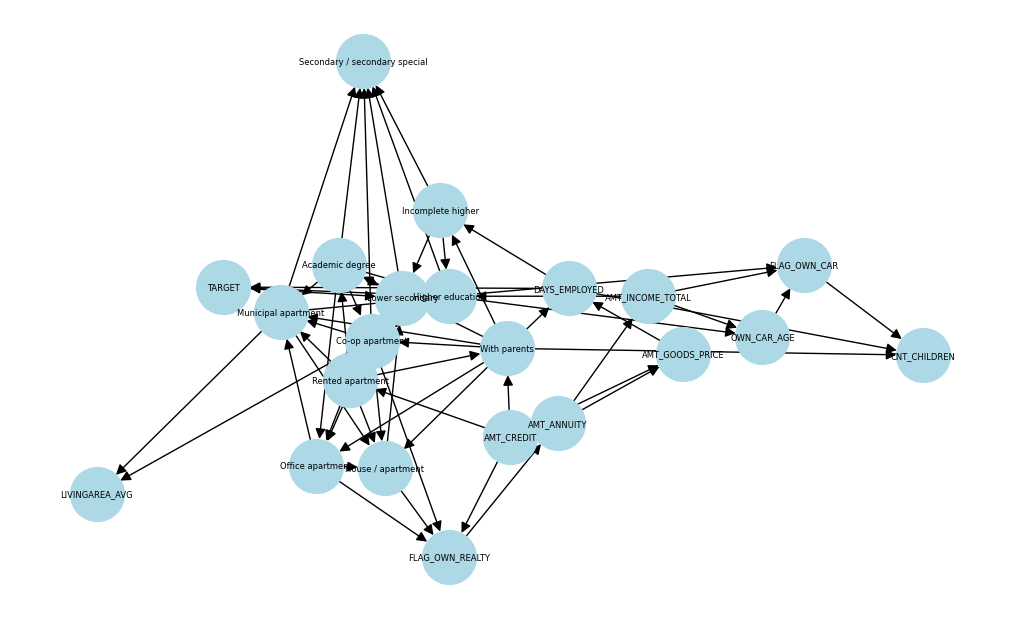

In [ ]:
import networkx as nx

plt.figure(figsize=(10, 6))

G = nx.DiGraph()

G.add_nodes_from(BN.nodes())
G.add_edges_from(BN.edges())

pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1500,
    font_size=6,
    node_color="lightblue",
    arrowsize=15
)

plt.show()


In [ ]:
!pip install -q pyvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 70.4 MB/s eta 0:00:00


In [ ]:
from pyvis.network import Network

Функцию взял из своего НИР

In [ ]:
def graph_vizualization(G, node_font_size=10, edge_font_size=8):
    net = Network(notebook=False, height="100%", width="100%", bgcolor="#ffffff", directed=True)

    net.repulsion(node_distance=150, spring_length=200, spring_strength=0.15)
    net.force_atlas_2based(gravity=-50, central_gravity=0.01, spring_length=200)

    for node in G.nodes():
        net.add_node(node, label=str(node), title=str(node),
                    font={'size': node_font_size})

    for source, target, data in G.edges(data=True):
        if 'relation' in data:
            net.add_edge(source, target, label=data['relation'], title=data['relation'],
                        font={'size': edge_font_size})
        else:
            net.add_edge(source, target, font={'size': edge_font_size})

    net.toggle_physics(True)


    net.barnes_hut(gravity=-3000, central_gravity=0.3, spring_length=250)

    net.show("knowledge_graph.html", notebook=False)

In [ ]:
graph_vizualization(G)

knowledge_graph.html


## Семплирование

In [ ]:
from pgmpy.sampling import BayesianModelSampling

In [ ]:
sampler = BayesianModelSampling(BN)

"""synthetic_minority = sampler.likelihood_weighted_sample(evidence=[("TARGET", 1)], size=25000)

synthetic_minority = synthetic_minority.drop("_weight", axis=1)"""

synthetic_minority = sampler.forward_sample(size=500000)
synthetic_minority = synthetic_minority[synthetic_minority["TARGET"]==1]
synthetic_minority.shape

  0%|          | 0/22 [00:00<?, ?it/s]

(43948, 22)

In [ ]:
synthetic_minority

,FLAG_OWN_CAR,CNT_CHILDREN,FLAG_OWN_REALTY,AMT_ANNUITY,DAYS_EMPLOYED,TARGET,Incomplete higher,AMT_INCOME_TOTAL,Higher education,OWN_CAR_AGE,...,With parents,Rented apartment,Lower secondary,Academic degree,Secondary / secondary special,Co-op apartment,Municipal apartment,Office apartment,LIVINGAREA_AVG,House / apartment
0,0,0,1,7,0,1,0,3,0,2,...,0,0,0,0,1,0,0,0,8,1
7,1,1,1,2,2,1,0,0,0,2,...,0,0,0,0,1,0,0,0,0,1
13,1,0,1,3,5,1,0,8,0,3,...,0,0,0,0,1,0,0,0,6,1
51,1,0,1,7,6,1,0,6,0,5,...,0,1,0,0,1,0,0,0,3,0
63,1,0,1,0,3,1,0,5,1,5,...,0,0,0,0,0,0,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499950,0,0,1,0,4,1,0,2,0,0,...,0,0,0,0,1,0,0,0,8,1
499958,0,1,1,6,6,1,0,2,0,3,...,0,0,0,0,1,0,0,0,4,1
499978,0,1,0,2,7,1,0,1,0,0,...,0,1,0,0,1,0,0,0,4,0
499980,0,0,1,6,2,1,0,5,1,0,...,0,0,0,0,0,0,0,0,5,1


In [ ]:
show_columns = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    "TARGET",

]
corr = data[show_columns].corr()
fig = px.imshow(corr.round(3), text_auto=True)
fig.show()

Данные с синтетикой

In [ ]:
tmp = pd.concat([data, synthetic_minority], ignore_index=True)[show_columns].corr()
fig = px.imshow(tmp.round(3), text_auto=True)
fig.show()

In [ ]:
data = pd.concat([data, pd.get_dummies(data[continuous_cols].astype(np.str_))], axis=1)
data = data.drop(columns=continuous_cols).astype(np.int64)
data

,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET,Academic degree,Higher education,Incomplete higher,Lower secondary,Secondary / secondary special,Co-op apartment,House / apartment,...,LIVINGAREA_AVG_0,LIVINGAREA_AVG_1,LIVINGAREA_AVG_2,LIVINGAREA_AVG_3,LIVINGAREA_AVG_4,LIVINGAREA_AVG_5,LIVINGAREA_AVG_6,LIVINGAREA_AVG_7,LIVINGAREA_AVG_8,LIVINGAREA_AVG_9
0,0,1,1,0,0,0,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,1,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,0,0,0,1,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307504,0,1,0,0,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0
307506,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
307508,0,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
307509,0,1,1,0,0,0,0,1,0,1,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
synthetic_minority = pd.concat([synthetic_minority, pd.get_dummies(synthetic_minority[continuous_cols].astype(np.str_))], axis=1)
synthetic_minority = synthetic_minority.drop(columns=continuous_cols).astype(np.int64)
synthetic_minority

,FLAG_OWN_CAR,FLAG_OWN_REALTY,TARGET,Incomplete higher,Higher education,With parents,Rented apartment,Lower secondary,Academic degree,Secondary / secondary special,...,LIVINGAREA_AVG_0,LIVINGAREA_AVG_1,LIVINGAREA_AVG_2,LIVINGAREA_AVG_3,LIVINGAREA_AVG_4,LIVINGAREA_AVG_5,LIVINGAREA_AVG_6,LIVINGAREA_AVG_7,LIVINGAREA_AVG_8,LIVINGAREA_AVG_9
0,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
7,1,1,1,0,0,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
13,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
51,1,1,1,0,0,0,1,0,0,1,...,0,0,0,1,0,0,0,0,0,0
63,1,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499950,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
499958,0,1,1,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
499978,0,0,1,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
499980,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## Визуализируем новые распределения - ТОЛЬКО ДЛЯ LABEL кодирования

In [ ]:
show_columns = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    #"NAME_EDUCATION_TYPE",
    #"NAME_HOUSING_TYPE",
    "OWN_CAR_AGE",
    "LIVINGAREA_AVG",
    "TARGET",

]
for col in show_columns:
  draw_distr(data[col], col)

## Обучение с данными баесовской сети
Синтетику добавляю только в train

In [ ]:
#scaler = StandardScaler()
X, y = data.drop("TARGET", axis=1), data.TARGET
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = pd.concat([X_train, synthetic_minority.drop("TARGET", axis=1)], ignore_index=True)
y_train = pd.concat([y_train, synthetic_minority.TARGET], ignore_index=True)

#X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
#X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [ ]:
X_train.shape

(235470, 82)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
prob = model.predict_proba(X_test)
y_pred = f1_th(y_test, prob[:, 1], show=False)
print(classification_report(y_test, y_pred))
print(f"ROC_AUC: {roc_auc_score(y_test, prob[:, 1])}")

Порог классификации 0.32
              precision    recall  f1-score   support

           0       0.93      0.77      0.85     43744
           1       0.14      0.39      0.21      4137

    accuracy                           0.74     47881
   macro avg       0.54      0.58      0.53     47881
weighted avg       0.86      0.74      0.79     47881

ROC_AUC: 0.6302241371513236


# Pomegranate

In [ ]:
!pip install -q git+https://github.com/jmschrei/pomegranate.git

  Preparing metadata (setup.py) ... done


In [ ]:
from pomegranate.bayesian_network import BayesianNetwork
from pomegranate.distributions import Categorical, Normal
import pomegranate

In [ ]:
pomegranate.__version__

'1.1.0'

In [ ]:
model = BayesianNetwork.from_samples(
    train.values,
    algorithm='exact',
    state_names=train.columns.tolist()
)

AttributeError: type object 'BayesianNetwork' has no attribute 'from_samples'

In [ ]:
BN.sample(100)

tensor([[-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -1, -1],
        [-1, -1, -1, -1, -1, -1, -